In [1]:
!pip install yfinance
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
ticker = "RELIANCE.NS"   # Reliance Industries on NSE. Use "AAPL" for Apple if you prefer US stocks
data = yf.download(ticker, start="2023-01-01", end="2026-07-01")
data.head()

/tmp/ipykernel_12925/2271463643.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2023-01-01", end="2026-07-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2023-01-02,1170.478027,1171.886668,1157.891242,1158.709143,5316175
2023-01-03,1161.912598,1169.160249,1157.709511,1165.547781,7658932
2023-01-04,1144.418213,1163.730055,1142.350684,1161.889687,9264891
2023-01-05,1142.373413,1152.529209,1137.806748,1146.667484,13637099
2023-01-06,1152.756348,1157.777455,1144.304622,1148.098818,6349597


In [3]:
data.index

DatetimeIndex(['2023-01-02', '2023-01-03', '2023-01-04', '2023-01-05',
               '2023-01-06', '2023-01-09', '2023-01-10', '2023-01-11',
               '2023-01-12', '2023-01-13',
               ...
               '2026-06-17', '2026-06-18', '2026-06-19', '2026-06-22',
               '2026-06-23', '2026-06-24', '2026-06-25', '2026-06-26',
               '2026-06-29', '2026-06-30'],
              dtype='datetime64[ns]', name='Date', length=863, freq=None)

In [4]:
data['Daily Return'] = data['Close'].pct_change() # (today - yesterday) / yesterday
data[['Close', 'Daily Return']].head(10)

Price,Close,Daily Return
Ticker,RELIANCE.NS,
Date,,
2023-01-02,1170.478027,NaN
2023-01-03,1161.912598,-0.007318
2023-01-04,1144.418213,-0.015057
2023-01-05,1142.373413,-0.001787
2023-01-06,1152.756348,0.009089
2023-01-09,1179.974731,0.023612
2023-01-10,1162.526001,-0.014787
2023-01-11,1147.871582,-0.012606


In [5]:
data['Cumulative Return'] = (1 + data['Daily Return']).cumprod() #cumulative product. (1 + daily_return)
data[['Close', 'Cumulative Return']].tail()

Price,Close,Cumulative Return
Ticker,RELIANCE.NS,
Date,,
2026-06-24,1313.599976,1.122276
2026-06-25,1318.099976,1.126121
2026-06-26,1318.099976,1.126121
2026-06-29,1301.000000,1.111512
2026-06-30,1293.900024,1.105446


In [6]:
data['Volatility (20d)'] = data['Daily Return'].rolling(window=20).std() # creates a "moving window" of the last 20 rows,.std() then calculates standard deviation
data[['Daily Return', 'Volatility (20d)']].tail(10)

Price,Daily Return,Volatility (20d)
Ticker,,
Date,,
2026-06-17,0.002935,0.011050
2026-06-18,-0.003452,0.010958
2026-06-19,-0.014005,0.011311
2026-06-22,0.012982,0.011526
2026-06-23,-0.012816,0.011729
2026-06-24,0.003131,0.011752
2026-06-25,0.003426,0.011794
2026-06-26,0.000000,0.010732


In [7]:
data['SMA_20'] = data['Close'].rolling(window=20).mean()
data['SMA_50'] = data['Close'].rolling(window=50).mean()

What to look for in each chart:

Chart 1: Watch for moments where SMA-20 crosses SMA-50 — these are the "signals" technical traders watch.

Chart 2: Most stocks' daily returns cluster near 0% in a roughly bell-shaped distribution — a visual gut-check for "how wild does this stock swing on a normal day."

Chart 3: Volatility isn't constant — you'll usually see spikes around news events, earnings, or market-wide stress periods.

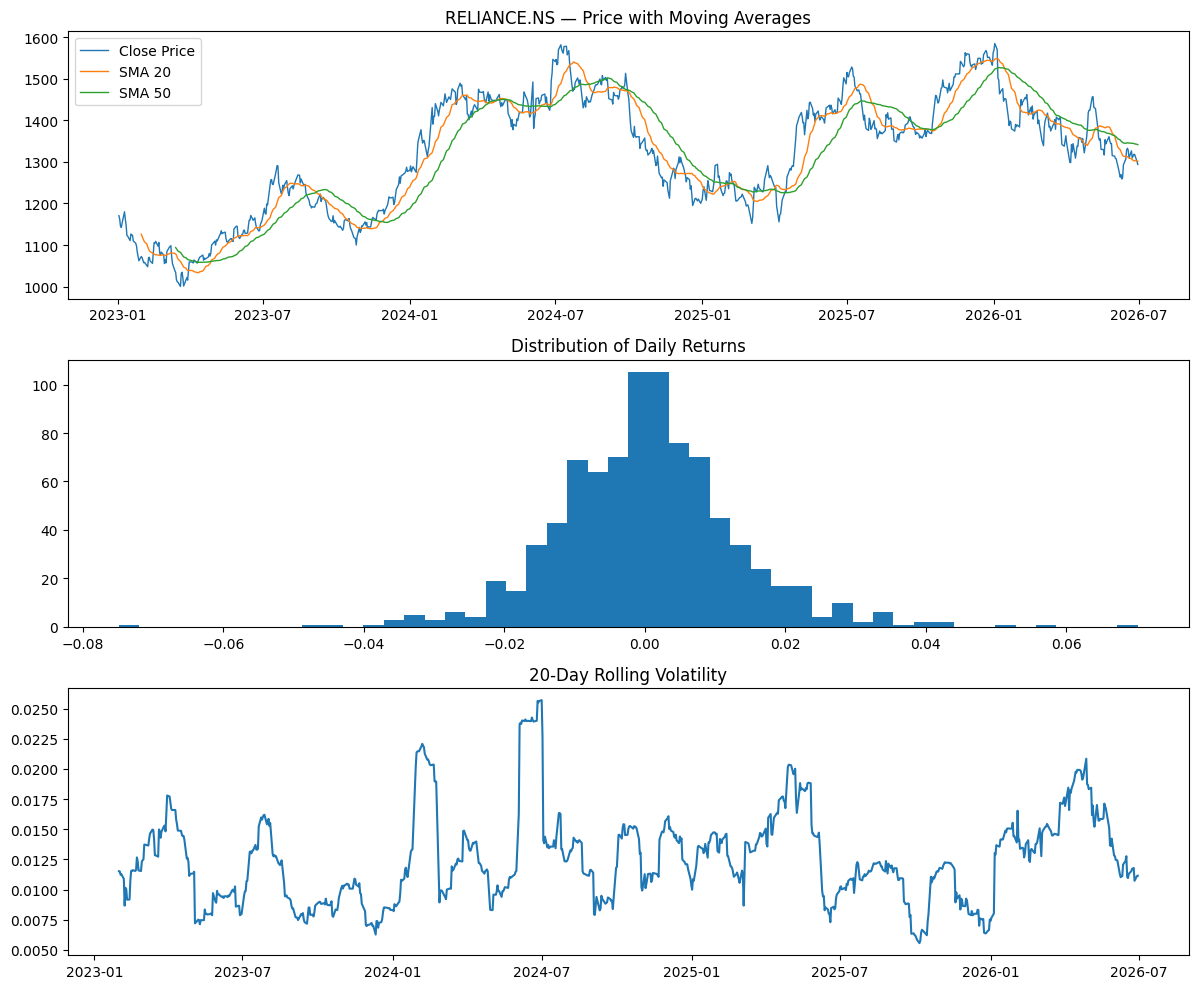

In [8]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

# Price with moving averages
axes[0].plot(data.index, data['Close'], label='Close Price', linewidth=1)
axes[0].plot(data.index, data['SMA_20'], label='SMA 20', linewidth=1)
axes[0].plot(data.index, data['SMA_50'], label='SMA 50', linewidth=1)
axes[0].set_title(f'{ticker} — Price with Moving Averages')
axes[0].legend()

# Daily returns distribution
axes[1].hist(data['Daily Return'].dropna(), bins=50)
axes[1].set_title('Distribution of Daily Returns')

# Rolling volatility
axes[2].plot(data.index, data['Volatility (20d)'])
axes[2].set_title('20-Day Rolling Volatility')

plt.tight_layout()
plt.show()

/tmp/ipykernel_12925/493788302.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  benchmark = yf.download(benchmark_ticker, start="2023-01-01", end="2026-07-01")
[*********************100%***********************]  1 of 1 completed


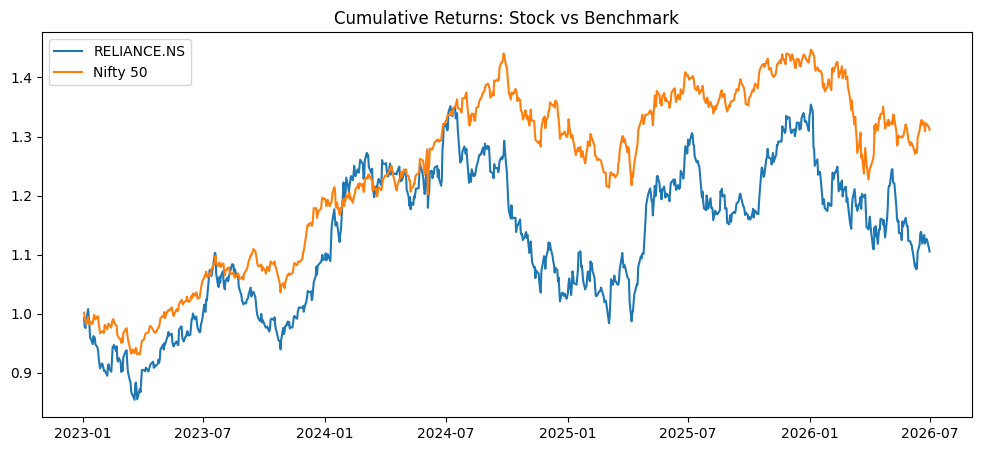

In [9]:
benchmark_ticker = "^NSEI"   # Nifty 50 index
benchmark = yf.download(benchmark_ticker, start="2023-01-01", end="2026-07-01")

benchmark['Daily Return'] = benchmark['Close'].pct_change()
benchmark['Cumulative Return'] = (1 + benchmark['Daily Return']).cumprod()

plt.figure(figsize=(12, 5))
plt.plot(data.index, data['Cumulative Return'], label=ticker)
plt.plot(benchmark.index, benchmark['Cumulative Return'], label='Nifty 50')
plt.title('Cumulative Returns: Stock vs Benchmark')
plt.legend()
plt.show()

## Analysis Notes

**Stock analyzed:** [ticker used-> RELIANCE.NS]
**Time period:** Jan 2023 – Jul 2026

**Observations:**
- Most daily returns clustered tightly between -2% and +2%, with a few outlier days showing larger spikes (both gains and losses).
- SMA-20 crossed above SMA-50 (bullish signal) around [2023-07,2024-07,2025-07,2026-01], which lined up with a price increase.
- Volatility (20-day rolling) was highest around 2024-07, possibly due to earnings, market news, etc.
-Comparing cumulative returns, RELIANCE.NS underperformed the Nifty 50 over this period."
"It's unclear whether the July 2024 volatility spike was stock-specific or market-wide — would need to check Nifty 50's volatility over the same window to confirm."